# MultiDiffusion panorama code

This notebook is a hands-on exploration of **MultiDiffusion**, a technique for generating images larger than what a diffusion model was originally trained on. Rather than fine-tuning the model or stitching outputs together naively, MultiDiffusion works by running the UNet denoiser on multiple overlapping windows of a latent at every denoising step, then averaging the predictions back into that latent weighted by how many windows covered each pixel.

The notebook implements this on top of Stable Diffusion to produce a wide panoramic image (`512×2048` pixels, or `64×256` in latent space). It walks through the full pipeline — loading the model weights, encoding text prompts, defining the sliding window grid, running the 50-step denoising loop across all 25 views, and finally decoding the latent back to pixels through the VAE. An inspection dashboard is also included, allowing you to visualise the internal state at any denoising step and any view window.

## Introduction

Import library

In [3]:
from transformers import CLIPTextModel, CLIPTokenizer, logging
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from huggingface_hub import hf_hub_download

# suppress partial model loading warning
logging.set_verbosity_error()

import torch
import torch.nn as nn
import torchvision.transforms as T

import argparse
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import json

# For the table
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.columns import Columns
from rich import box
from rich.console import Group

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


**seed_everything** is used to ensure reproducibility in the experiments.

In [4]:
def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = True

**get_views** is a core utility for MultiDiffusion. It calculates the coordinates for a "sliding window" that moves across a latent to break it down into smaller, manageable overlapping views.

In [5]:
def get_views(panorama_height, panorama_width, window_size=64, stride=8):
    panorama_height /= 8
    panorama_width /= 8
    num_blocks_height = (panorama_height - window_size) // stride + 1
    num_blocks_width = (panorama_width - window_size) // stride + 1
    total_num_blocks = int(num_blocks_height * num_blocks_width)
    views = []
    for i in range(total_num_blocks):
        h_start = int((i // num_blocks_width) * stride)
        h_end = h_start + window_size
        w_start = int((i % num_blocks_width) * stride)
        w_end = w_start + window_size
        views.append((h_start, h_end, w_start, w_end))
    return views

The following classes are needed just to record every time step of the model:
- **RecordGeneration**: record every latent or tensor for exploring the Panorama generation
- **RecordViews**: record all the tensor for a specific timestep


In [6]:
# Recording class for saving tensors about all the views of a denoising step
class RecordViews():
  def __init__(self):
    self.latents_view = []
    self.latents_view_denoised = []
    self.values = []
    self.counts = []
    self.views = []

# General class for recording tensor in MultiDiffusion process
class RecordGeneration():
  def __init__(self):
    self.init_bootstrapping_backgrounds = None
    self.init_latent = None
    self.init_views = None
    self.init_count = None
    self.init_value = None

    # 'views' is a list of 'RecordViews' objects
    self.views = []
    self.latent = []

## Model

Whenever you define a **custom NN** in PyTorch, you will typically do so by creating a Python class that inherits from **nn.Module**. This inheritance provides your custom class with a significant amount of built-in functionality essential for deep learning workflows.

In [7]:
class MultiDiffusion(nn.Module):
    def __init__(self, device, sd_version='2.0', hf_key=None, rec = False):
        super().__init__()

        self.rec = rec
        self.device = device
        self.sd_version = sd_version

        # Choose the model key to create the model
        print(f'[INFO] loading stable diffusion...')
        if hf_key is not None:
            print(f'[INFO] using hugging face custom model key: {hf_key}')
            model_key = hf_key
        elif self.sd_version == '2.1':
            model_key = "stabilityai/stable-diffusion-2-1-base"
        elif self.sd_version == '2.0':
            model_key = "stabilityai/stable-diffusion-2-base"
        elif self.sd_version == '1.5':
            model_key = "runwayml/stable-diffusion-v1-5"
        else:
            raise ValueError(f'Stable-diffusion version {self.sd_version} not supported.')

        print(f"[INFO] model key choosen: {model_key}")

        # Create model
        self.vae = AutoencoderKL.from_pretrained(model_key, subfolder="vae").to(self.device)
        print(f"[INFO] loaded: {type(self.vae).__name__}")

        self.tokenizer = CLIPTokenizer.from_pretrained(model_key, subfolder="tokenizer")
        print(f"[INFO] loaded: {type(self.tokenizer).__name__}")

        self.text_encoder = CLIPTextModel.from_pretrained(model_key, subfolder="text_encoder").to(self.device)
        print(f"[INFO] loaded: {type(self.text_encoder).__name__}")

        self.unet = UNet2DConditionModel.from_pretrained(model_key, subfolder="unet").to(self.device)
        print(f"[INFO] loaded: {type(self.unet).__name__}")

        self.scheduler = DDIMScheduler.from_pretrained(model_key, subfolder="scheduler")
        print(f"[INFO] loaded: {type(self.scheduler).__name__}")

        print(f'[INFO] loaded stable diffusion!')

        # Initialize the object that takes trace of the main tensors
        if self.rec:
          self.rec_gen = RecordGeneration()

    @torch.no_grad()
    def get_text_embeds(self, prompt, negative_prompt):
        # prompt, negative_prompt: [str]

        # Tokenize text and get embeddings
        text_input = self.tokenizer(prompt, padding='max_length', max_length=self.tokenizer.model_max_length,
                                    truncation=True, return_tensors='pt')
        text_embeddings = self.text_encoder(text_input.input_ids.to(self.device))[0]

        # Do the same for unconditional embeddings
        uncond_input = self.tokenizer(negative_prompt, padding='max_length', max_length=self.tokenizer.model_max_length,
                                      return_tensors='pt')

        uncond_embeddings = self.text_encoder(uncond_input.input_ids.to(self.device))[0]

        # Cat for final embeddings
        text_embeddings = torch.cat([uncond_embeddings, text_embeddings])
        return text_embeddings

    @torch.no_grad()
    def decode_latents(self, latents):
        latents = 1 / 0.18215 * latents
        imgs = self.vae.decode(latents).sample
        imgs = (imgs / 2 + 0.5).clamp(0, 1)
        return imgs

    @torch.no_grad()
    def text2panorama(self, prompts, negative_prompts='', height=512, width=2048, num_inference_steps=50,
                      guidance_scale=7.5):

        if isinstance(prompts, str):
            prompts = [prompts]

        if isinstance(negative_prompts, str):
            negative_prompts = [negative_prompts]

        # Prompts -> text embeds
        text_embeds = self.get_text_embeds(prompts, negative_prompts)  # [2, 77, 768]

        # Define panorama grid and get views
        #latent = torch.randn((1, self.unet.in_channels, height // 8, width // 8), device=self.device)
        latent = torch.randn((1, self.unet.config.in_channels, height // 8, width // 8), device=self.device)
        views = get_views(height, width)
        count = torch.zeros_like(latent)
        value = torch.zeros_like(latent)

        # RECORD
        if self.rec:
          self.rec_gen.init_latent = latent
          self.rec_gen.init_views = views
          self.rec_gen.init_count = count
          self.rec_gen.init_value = value

        self.scheduler.set_timesteps(num_inference_steps)

        with torch.autocast('cuda'):
            for i, t in enumerate(tqdm(self.scheduler.timesteps)):
                count.zero_()
                value.zero_()

                if self.rec:
                  record_view = RecordViews()

                for h_start, h_end, w_start, w_end in views:
                    # TODO we can support batches, and pass multiple views at once to the unet
                    latent_view = latent[:, :, h_start:h_end, w_start:w_end]

                    # expand the latents if we are doing classifier-free guidance to avoid doing two forward passes.
                    latent_model_input = torch.cat([latent_view] * 2)

                    # predict the noise residual
                    noise_pred = self.unet(latent_model_input, t, encoder_hidden_states=text_embeds)['sample']

                    # perform guidance
                    noise_pred_uncond, noise_pred_cond = noise_pred.chunk(2)
                    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)

                    # compute the denoising step with the reference model
                    latents_view_denoised = self.scheduler.step(noise_pred, t, latent_view)['prev_sample']
                    value[:, :, h_start:h_end, w_start:w_end] += latents_view_denoised
                    count[:, :, h_start:h_end, w_start:w_end] += 1

                    if self.rec:
                      record_view.latents_view.append(latent_view)
                      record_view.latents_view_denoised.append(latents_view_denoised)
                      record_view.values.append(value.detach().clone())
                      record_view.counts.append(count.detach().clone())

                # take the MultiDiffusion step
                latent = torch.where(count > 0, value / count, value)

                # RECORD
                if self.rec:
                  self.rec_gen.views.append(record_view)
                  self.rec_gen.latent.append(latent)

        # Img latents -> imgs
        imgs = self.decode_latents(latent)  # [1, 3, 512, 512]
        img = T.ToPILImage()(imgs[0].cpu())
        return img


## Settings (Panorama)

We prepare the settings and instantiate the MultiDiffusion model. Key parameter explanations:
- **H**: height of the panorama.
- **W** = 2048: traditional Stable Diffusion cannot generate a 2048-pixel wide image in one go (it would create repeated objects or "ghosting"). MultiDiffusion solves this by breaking this 2048 width into overlapping **512 x 512** windows and diffusing them simultaneously.
- **prompt**: this is the description of what you want to see. In MultiDiffusion, this prompt is applied to every single "window" (tile) that the model processes across the 2048-pixel width
- **negative**: this tells the model what to exclude from the entire generation. Negative prompts are essential in Stable Diffusion to steer the model away from common AI "mistakes.

- **sd_version**: stable diffusion version. It can be chosen between 1.5, 2.0
- **seed** (REPRODUCIBILITY): use a fixed seed for consistent testing
- **steps** (QUALITY): 50 steps is standard for high quality
- **outfile**: output path of the final image

In [8]:
# Settings for the model (panorama case)
class Settings():
    def __init__(self):
      self.prompt   = "a breathtaking panoramic view of the Dolomites at sunset, high quality, 8k"
      self.negative = "artifacts, blurry, bad quality, distorted"
      self.sd_version = '1.5'
      self.H = 512
      self.W = 2048
      self.seed = 0
      self.steps = 50
      self.outfile = "out.png"

**get_model_subfolders** is a lightweight inspection utility that retrieves the model_index.json file from a HuggingFace Hub repository — downloading only that small metadata file rather than the full model weights — and prints the list of components that make up the pipeline.

Each component entry in the JSON is a pair of [library, class_name], for example ["diffusers", "UNet2DConditionModel"] or ["transformers", "CLIPTextModel"], and corresponds to a real subfolder in the repository.

Keys prefixed with _ are internal metadata and are filtered out. The result is a quick, readable overview of exactly which building blocks a given model is composed of, useful for understanding a pipeline's structure before committing to a full download.

In [9]:
# Function to inspect the metadata of the key model
def get_model_subfolders(model_key):
    try:
        # Download only the model_index.json file
        filename = hf_hub_download(repo_id=model_key, filename="model_index.json")

        with open(filename, "r") as f:
            data = json.load(f)

        print(f"\033[1m--- Components for {model_key} ---\033[0m")

        # Filter out metadata (keys starting with '_') to see actual subfolders
        subfolders = {k: v for k, v in data.items() if not k.startswith("_")}

        for folder, info in subfolders.items():
            # info is usually a list: [library_name, class_name]
            # e.g., ["diffusers", "UNet2DConditionModel"]
            library = info[0]
            class_name = info[1]
            print(f"Subfolder: '{folder}'")
            print(f"  - Library: {library}")
            print(f"  - Class:   {class_name}\n")

    except Exception as e:
        print(f"Error fetching model index: {e}")

# Example
get_model_subfolders("runwayml/stable-diffusion-v1-5")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

--- Components for runwayml/stable-diffusion-v1-5 ---
Subfolder: 'feature_extractor'
  - Library: transformers
  - Class:   CLIPImageProcessor

Subfolder: 'safety_checker'
  - Library: stable_diffusion
  - Class:   StableDiffusionSafetyChecker

Subfolder: 'scheduler'
  - Library: diffusers
  - Class:   PNDMScheduler

Subfolder: 'text_encoder'
  - Library: transformers
  - Class:   CLIPTextModel

Subfolder: 'tokenizer'
  - Library: transformers
  - Class:   CLIPTokenizer

Subfolder: 'unet'
  - Library: diffusers
  - Class:   UNet2DConditionModel

Subfolder: 'vae'
  - Library: diffusers
  - Class:   AutoencoderKL



Initialize the model with the previous settings.

The parameter *rec* is to True in order to inspect the code with the dashboard

In [10]:
opt = Settings()

seed_everything(opt.seed)

device = torch.device('cuda')

sd = MultiDiffusion(device, opt.sd_version, rec=True)

[INFO] loading stable diffusion...
[INFO] model key choosen: runwayml/stable-diffusion-v1-5


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

[INFO] loaded: AutoencoderKL


...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

[INFO] loaded: UNet2DConditionModel


scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

[INFO] loaded: DDIMScheduler
[INFO] loaded stable diffusion!


## Generation (Panorama)

Now, we can start the generation of the image

In [11]:
# Generate the panorama
img = sd.text2panorama(opt.prompt, opt.negative, opt.H, opt.W, opt.steps)

# save image
img.save(opt.outfile)

100%|██████████| 50/50 [03:33<00:00,  4.26s/it]


Explore the tensor recorded during generation through the following dashboard.

This code creates an Interactive Inspection Dashboard designed to visualize the internal mechanics of the MultiDiffusion process. It allows you to "look under the hood" of how the panoramic image is being constructed piece by piece.

What happens in the code:

1) Interactive Selection: Using Google Colab sliders, you choose a specific diffusion step (temporal progress) and a specific view index (spatial segment).

2) Visualization
   *   **Global Visualization** (Row 1):
   
        * It displays the **Full Latent state** at that specific step, showing the raw mathematical representation of the image.
        
        * It **decodes that latent** into a **viewable image**, allowing you to see how the panorama looks as it emerges from the noise.

   *   **Local View Inspection** (Row 2):

        * **Values** & **Counts**: It visualizes the "Values" (the accumulated pixel data) and "Counts" (how many times each pixel has been processed by overlapping windows).

        * **Spatial Context**: It draws a cyan rectangle (bounding box) over these maps to show exactly where the currently selected view is located within the global panorama.

        * **Masking**: It creates a binary map ("Multidiffusion step area") to highlight exactly which parts of the latent are being actively updated during that specific step.

In [12]:
# Get the tensors saved
records = sd.rec_gen

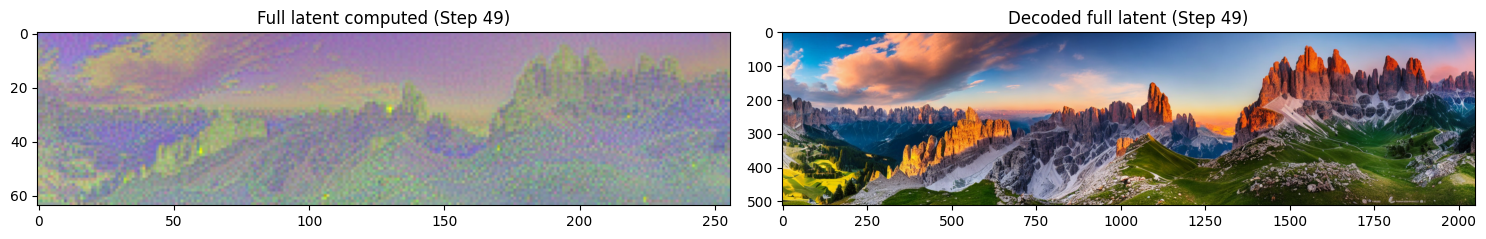

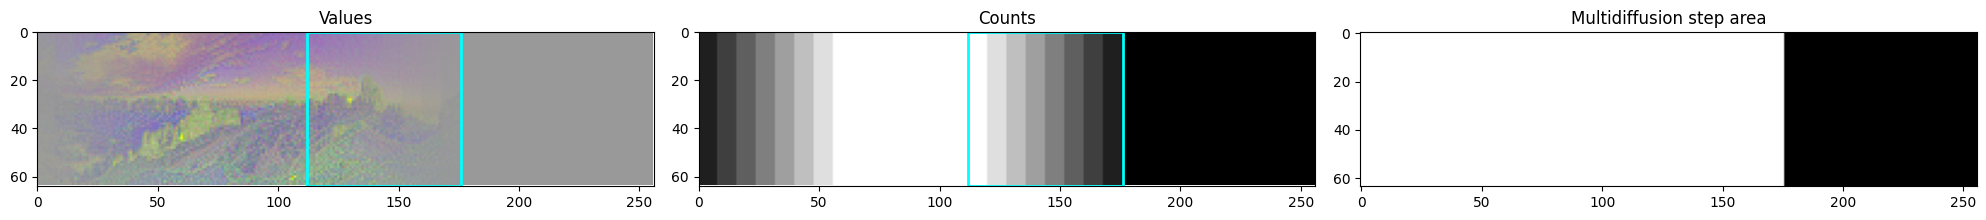

In [43]:
# @title 🖼️ MultiDiffusion Inspection Dashboard { run: "auto" }
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

# @markdown ### 1. Select Global Progress
step_idx = 49 # @param {type:"slider", min:0, max:49, step:1}

# @markdown ### 2. Select Specific View
view_idx = 14 # @param {type:"slider", min:0, max:24, step:1}

def show_lat(tensor, title, ax=None):
    if tensor is None: return
    target = ax or plt.gca()
    img = tensor.detach()[0, :3].cpu().permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    target.imshow(img)
    target.set_title(title)
    return target

def add_view_frame(ax, h_start, h_end, w_start, w_end, H, W):
    ax.add_patch(patches.Rectangle(
        (w_start, h_start),
        w_end - w_start,
        h_end - h_start,
        linewidth=2,
        edgecolor='cyan',
        facecolor='none',
    ))
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)

step_idx = min(step_idx, len(sd.rec_gen.latent) - 1)
current_view_record = sd.rec_gen.views[step_idx]
view_idx = min(view_idx, len(current_view_record.latents_view) - 1)

h_start, h_end, w_start, w_end = sd.rec_gen.init_views[view_idx]
_, _, H, W = current_view_record.values[view_idx].shape

# --- ROW 1: Global State ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
show_lat(sd.rec_gen.latent[step_idx], f"Full latent computed (Step {step_idx})", axes[0])
imgs = sd.decode_latents(sd.rec_gen.latent[step_idx])
axes[1].imshow(T.ToPILImage()(imgs[0].cpu()))
axes[1].set_title(f"Decoded full latent (Step {step_idx})")
plt.tight_layout(); plt.show()

# --- ROW 2: Values + Counts + Highlight, all with frame ---
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

show_lat(current_view_record.values[view_idx], "Values", axes[0])
add_view_frame(axes[0], h_start, h_end, w_start, w_end, H, W)

show_lat(current_view_record.counts[view_idx], "Counts", axes[1])
add_view_frame(axes[1], h_start, h_end, w_start, w_end, H, W)

count_i = current_view_record.counts[view_idx]
show_lat(torch.where(count_i > 0, 255, 0), "Multidiffusion step area", axes[2])

plt.tight_layout()
plt.show()

The following cell provides a structured summary of the recorded generation state after running MultiDiffusion. The top panel group confirms the key dimensions of the run: 25 sliding windows, 50 denoising steps, and the fact that every per-step record holds exactly 25 entries across all four buffers (latents_view, latents_view_denoised, values, counts).

The table below maps each of the 25 views to its exact position on the latent, making it immediately visible that the windows scan horizontally with a fixed stride of 8, all sharing the same full height of 64.



In [39]:
console = Console()

# --- Summary stats ---
n_views   = len(sd.rec_gen.init_views)
n_steps   = len(sd.rec_gen.views)
n_latents = len(sd.rec_gen.latent)
rc_view   = sd.rec_gen.views[0]

from rich.table import Table
from rich.panel import Panel
from rich.console import Console

console = Console()

# --- First Row ---
row1 = Panel(f"[bold cyan]{n_latents}[/]", title="latents", expand=False)

# --- The "Step 0" Info Grouped (The Layout Grid) ---
# We use a Table instead of Columns to control width tightly
grid = Table.grid(padding=1) # This creates a container with no borders
grid.add_row(
    Panel(f"[bold cyan]{len(rc_view.latents_view)}[/]", title="latents_view", expand=False),
    Panel(f"[bold cyan]{len(rc_view.latents_view_denoised)}[/]", title="denoised", expand=False),
    Panel(f"[bold cyan]{len(rc_view.values)}[/]", title="values", expand=False),
    Panel(f"[bold cyan]{len(rc_view.counts)}[/]", title="counts", expand=False)
)

# Put the grid inside the frame
# expand=False here is now effective because the Table grid doesn't force width
row2_3_frame = Panel(
    grid,
    title="[bold blue]Step 0 Information (sample step)[/]",
    expand=False
)

# --- Final Print ---
console.print(row1)
console.print(row2_3_frame)

print("\n\n")

# --- Views coordinate table ---
table = Table(
    title="views — window coordinates",
    box=box.ROUNDED,
    header_style="bold magenta",
    show_lines=False,
)
table.add_column("view", justify="right",  style="dim")
table.add_column("h_start", justify="right")
table.add_column("h_end",   justify="right")
table.add_column("w_start", justify="right")
table.add_column("w_end",   justify="right")
table.add_column("h_size",  justify="right", style="cyan")
table.add_column("w_size",  justify="right", style="cyan")

for i, (h_start, h_end, w_start, w_end) in enumerate(sd.rec_gen.init_views):
    table.add_row(
        str(i),
        str(h_start), str(h_end),
        str(w_start), str(w_end),
        str(h_end - h_start),
        str(w_end - w_start),
    )

console.print(table)

╭─ latents ─╮
│ 50        │
╰───────────╯

╭───────────── Step 0 Information (sample step) ──────────────╮
│ ╭─ latents_view ─╮ ╭─ denoised ─╮ ╭─ values ─╮ ╭─ counts ─╮ │
│ │ 25             │ │ 25         │ │ 25       │ │ 25       │ │
│ ╰────────────────╯ ╰────────────╯ ╰──────────╯ ╰──────────╯ │
╰─────────────────────────────────────────────────────────────╯

                  views — window coordinates                  
╭──────┬─────────┬───────┬─────────┬───────┬────────┬────────╮
│ view │ h_start │ h_end │ w_start │ w_end │ h_size │ w_size │
├──────┼─────────┼───────┼─────────┼───────┼────────┼────────┤
│    0 │       0 │    64 │       0 │    64 │     64 │     64 │
│    1 │       0 │    64 │       8 │    72 │     64 │     64 │
│    2 │       0 │    64 │      16 │    80 │     64 │     64 │
│    3 │       0 │    64 │      24 │    88 │     64 │     64 │
│    4 │       0 │    64 │      32 │    96 │     64 │     64 │
│    5 │       0 │    64 │      40 │   104 │     64 │     64 │
│    6 │       0 │    64 │      48 │   112 │     64 │     64 │
│    7 │       0 │    64 │      56 │   120 │     64 │     64 │
│    8 │       0 │    64 │      64 │   128 │     64 │     64 │
│    9 │       0 │    64 │      72 │   136 │     64 │     64 │
│   10 │       0 │    64 │      80 │   144 │     64 │     64 │
│   11 │       0 │    64 │      88 │   152 │     64 │     64 │
│   12 │       0 │    64 │      96 │   160 │     64 │     64 │
│   13 │       0 │    64 │     104 │   168 │     64 │     64 │
│   14 │       0 │    64 │     112 │   176 │     64 │     64 │
│   15 │       0 │    64 │     120 │   184 │     64 │     64 │
│   16 │       0 │    64 │     128 │   192 │     64 │     64 │
│   17 │       0 │    64 │     136 │   200 │     64 │     64 │
│   18 │       0 │    64 │     144 │   208 │     64 │     64 │
│   19 │       0 │    64 │     152 │   216 │     64 │     64 │
│   20 │       0 │    64 │     160 │   224 │     64 │     64 │
│   21 │       0 │    64 │     168 │   232 │     64 │     64 │
│   22 │       0 │    64 │     176 │   240 │     64 │     64 │
│   23 │       0 │    64 │     184 │   248 │     64 │     64 │
│   24 │       0 │    64 │     192 │   256 │     64 │     64 │
╰──────┴─────────┴───────┴─────────┴───────┴────────┴────────╯

Looking at this output, the MultiDiffusion setup is doing a **1D horizontal scan** over a fixed-height canvas:

- **Latent space** has size `64 × 256` (H × W). Every single view has `h_start=0, h_end=64`, meaning the full height is always covered — there is no vertical sliding at all. Only the width axis moves.

- **The 25 views are a sliding window** stepping `+8` pixels to the right each time, from `w_start=0` up to `w_start=192`. Each window is `64×64`, so neighbouring views overlap by `64 - 8 = 56` pixels — a **~87% overlap**, which is very high and is what makes MultiDiffusion blend smoothly.

- **The 50 steps** are the standard diffusion denoising timesteps. At each step, all 25 views are processed independently by the UNet, then blended back into the shared latent via the accumulated `values / counts` buffers. So the total number of UNet forward passes is `50 steps × 25 views = 1250`.

- **The symmetry** — `init_views`, `latents_view`, `latents_view_denoised`, `values`, and `counts` all having length 25 — confirms that one record entry exists per view per step, exactly as expected.

- **In short**: this is generating a panoramic `64×256` latent by sliding a `64×64` UNet window horizontally with stride 8, blending overlapping predictions at every denoising step.